## 1. Data Pipeline Initialization

In [2]:
import torch
from torch.utils.data import DataLoader
import nltk
from nltk.corpus import gutenberg

from preprocessing import build_vocab, create_negative_sampling_distribution
from dataset import generate_skipgram_pairs, SkipGramDataset
from model import Word2VecSkipGram

In [5]:
# Download and load corpus
nltk.download("gutenberg")
tokens = [token.lower() for token in gutenberg.words("carroll-alice.txt")]

# Build vocabulary filtering rare tokens
word_to_idx, idx_to_word = build_vocab(tokens, min_count=2)
filtered_tokens = [token for token in tokens if token in word_to_idx]
pairs = generate_skipgram_pairs(filtered_tokens, window_size=2)

dataset = SkipGramDataset(pairs, word_to_idx)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

negative_probs = create_negative_sampling_distribution(tokens, word_to_idx)

[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


## 2. Model Training Loop

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Word2VecSkipGram(len(word_to_idx), embedding_dim=50).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

epochs, num_negatives = 15, 5

for epoch in range(epochs):
    total_loss = 0.0
    for center_ids, context_ids in dataloader:
        center_ids = center_ids.to(device)
        context_ids = context_ids.to(device)
        
        # Sample negative context words
        batch_size = center_ids.size(0)
        neg_ids = torch.multinomial(
            negative_probs, 
            num_samples=batch_size * num_negatives, 
            replacement=True
        ).view(batch_size, num_negatives).to(device)

        optimizer.zero_grad()
        pos_scores, neg_scores = model(center_ids, context_ids, neg_ids)
        loss = model.loss(pos_scores, neg_scores)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss / len(dataloader):.4f}")

Epoch 1/15 | Loss: 4.5337
Epoch 2/15 | Loss: 3.1424
Epoch 3/15 | Loss: 2.4725
Epoch 4/15 | Loss: 2.0846
Epoch 5/15 | Loss: 1.8360
Epoch 6/15 | Loss: 1.6726
Epoch 7/15 | Loss: 1.5553
Epoch 8/15 | Loss: 1.4585
Epoch 9/15 | Loss: 1.3836
Epoch 10/15 | Loss: 1.3221
Epoch 11/15 | Loss: 1.2711
Epoch 12/15 | Loss: 1.2273
Epoch 13/15 | Loss: 1.1920
Epoch 14/15 | Loss: 1.1617
Epoch 15/15 | Loss: 1.1333


## 3. Nearest Neighbors Evaluation

In [7]:
import torch.nn.functional as F

def get_similar_words(target_word, top_k=5):
    if target_word not in word_to_idx:
        return f"'{target_word}' not found in vocabulary."
    
    # Normalize input embeddings for cosine similarity
    embeddings = model.input_embeddings.weight.data
    norm_embeddings = F.normalize(embeddings, p=2, dim=1)
    
    target_idx = word_to_idx[target_word]
    target_vec = norm_embeddings[target_idx].unsqueeze(0)
    
    similarities = torch.mm(target_vec, norm_embeddings.T).squeeze(0)
    top_indices = torch.topk(similarities, k=top_k + 1).indices.tolist()
    
    return [idx_to_word[idx] for idx in top_indices if idx != target_idx][:top_k]

print("Similar to 'alice':", get_similar_words("alice"))
print("Similar to 'queen':", get_similar_words("queen"))

Similar to 'alice': ['witness', 'turtle', 'replied', 'he', 'ran']
Similar to 'queen': ['silence', 'march', 'bank', 'cross', 'day']


## 4. Dimensionality Reduction & Plotting

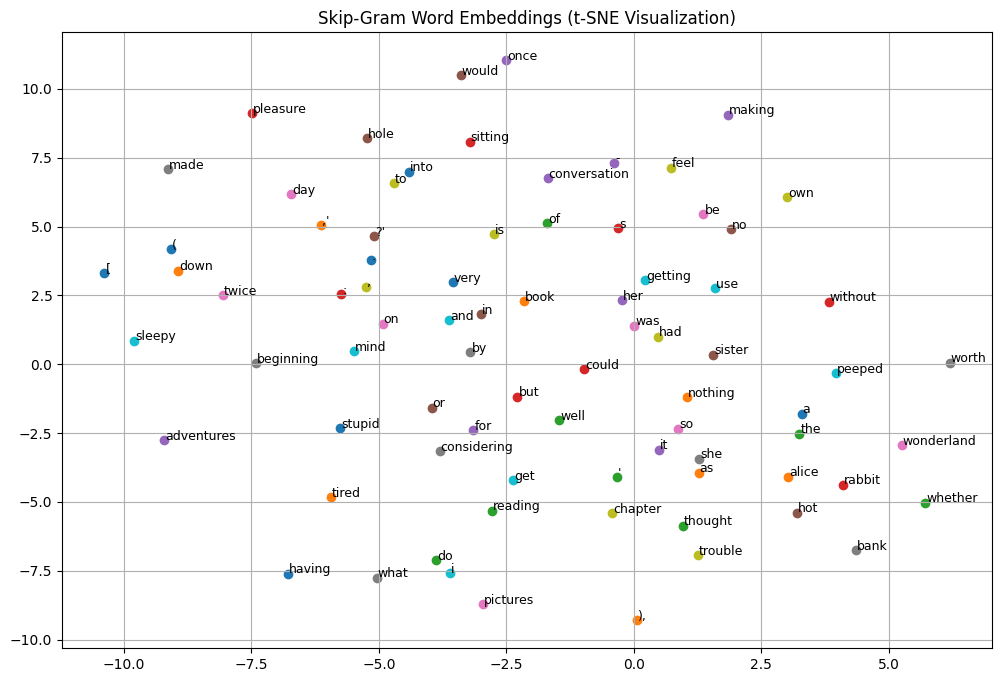

In [8]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Select top 80 frequent words
sample_words = list(word_to_idx.keys())[:80]
sample_indices = [word_to_idx[w] for w in sample_words]
vectors = model.input_embeddings.weight.data[sample_indices].cpu().numpy()

# Map 50D vectors to 2D
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
vectors_2d = tsne.fit_transform(vectors)

plt.figure(figsize=(12, 8))
for i, word in enumerate(sample_words):
    plt.scatter(vectors_2d[i, 0], vectors_2d[i, 1])
    plt.annotate(word, (vectors_2d[i, 0] + 0.02, vectors_2d[i, 1] + 0.02), fontsize=9)
plt.title("Skip-Gram Word Embeddings (t-SNE Visualization)")
plt.grid(True)
plt.show()